### [CounterStrike: Match statistics for Counter Strike Global Offensive](https://www.kaggle.com/datasets/thesiff/counterstrike)

> [K-Means Clustering](https://medium.com/@ahmadbintangarif/k-means-clustering-with-r-abdb10448cc1)

In [12]:
system("kaggle datasets download thesiff/counterstrike && unzip -o counterstrike.zip && rm counterstrike.zip")
system("apt-get install r-cran-factoextra")

In [13]:
options(Ncpus = 2)
system("apt-get install build-essential libcurl4-gnutls-dev libxml2-dev libssl-dev libnlopt-dev")
# install.packages("factoextra")

# Library
library(readr)
library(factoextra)

In [14]:
# Input dataset to R
data <- read.csv("/content/CSGOComplete.csv", row.names = NULL)
str(data) # see detail data

'data.frame':	1133 obs. of  17 variables:
 $ Map          : chr  "Mirage" "Mirage" "Mirage" "Mirage" ...
 $ Day          : int  3 2 31 31 30 29 28 27 27 27 ...
 $ Month        : int  8 8 7 7 7 7 7 7 7 7 ...
 $ Year         : int  2018 2018 2018 2018 2018 2018 2018 2018 2018 2018 ...
 $ Date         : chr  "3/8/2018" "2/8/2018" "31/7/2018" "31/7/2018" ...
 $ Wait.Time.s. : int  327 336 414 317 340 391 274 291 184 375 ...
 $ Match.Time.s.: int  2906 2592 2731 2379 3467 1881 3194 2859 2300 2184 ...
 $ Team.A.Rounds: int  16 16 16 11 15 16 16 16 16 6 ...
 $ Team.B.Rounds: int  13 11 14 16 15 4 14 14 8 16 ...
 $ Ping         : int  215 199 85 93 94 88 89 82 112 89 ...
 $ Kills        : int  17 13 15 12 33 13 19 17 25 13 ...
 $ Assists      : int  2 4 3 2 5 2 5 1 10 1 ...
 $ Deaths       : int  21 24 18 15 20 17 24 25 12 17 ...
 $ Mvp.s        : int  2 2 3 2 5 1 2 0 4 0 ...
 $ HS.          : int  5 0 26 16 30 38 15 35 16 61 ...
 $ Points       : int  45 40 37 30 83 34 52 37 70 31 ...
 $ Resu

In [15]:
# Set the first column to be the row name
baru <- data[,-1] # Delete first column
rownames(baru) <- make.names(data$Map, unique = TRUE)

In [16]:
# Selecting sample data by taking 50 random data
# Select a data column with numeric type
databaru <- baru[sample(nrow(data), 50),c(6:15)]

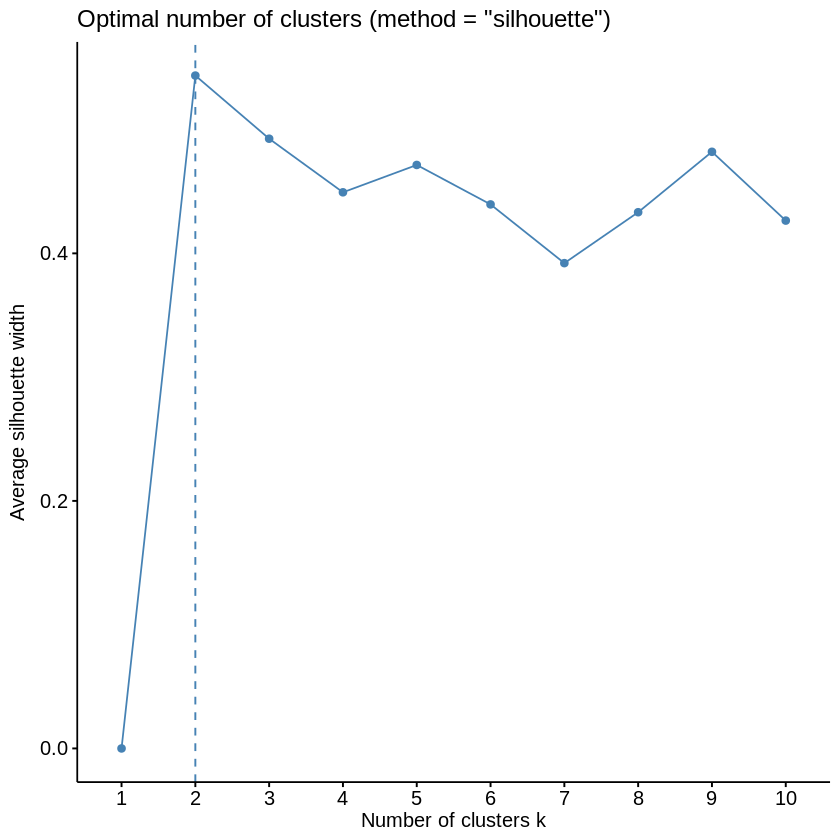

In [17]:
# Finding the Optimal Number of Clusters with the Silhouette Method
fviz_nbclust(databaru, kmeans, method = "silhouette")

In [18]:
# Computing Kmeans with k = 2
kmeans.awal <- kmeans(databaru,2)
kmeans.awal

K-means clustering with 2 clusters of sizes 25, 25

Cluster means:
  Match.Time.s. Team.A.Rounds Team.B.Rounds  Ping Kills Assists Deaths Mvp.s
1       1907.72         11.80          9.68 64.40 12.92    2.96  15.40  1.76
2       2653.12         14.36         13.32 66.88 15.08    4.60  18.24  2.04
    HS. Points
1 24.64  33.32
2 23.64  42.24

Clustering vector:
   Cache.45 Inferno.128   Mirage.33   Mirage.73  Inferno.13  Mirage.114 
          1           1           1           1           1           1 
Dust.II.393    Cache.42  Mirage.272 Inferno.101 Dust.II.455  Mirage.361 
          1           2           2           2           2           2 
 Mirage.253   Mirage.59  Mirage.237  Mirage.129  Inferno.67   Mirage.27 
          2           2           1           2           2           2 
 Mirage.216 Dust.II.284  Mirage.183  Dust.II.64  Mirage.105 Dust.II.130 
          2           1           1           1           1           2 
Dust.II.292    Cache.38 Dust.II.237 Dust.II.200  Dust

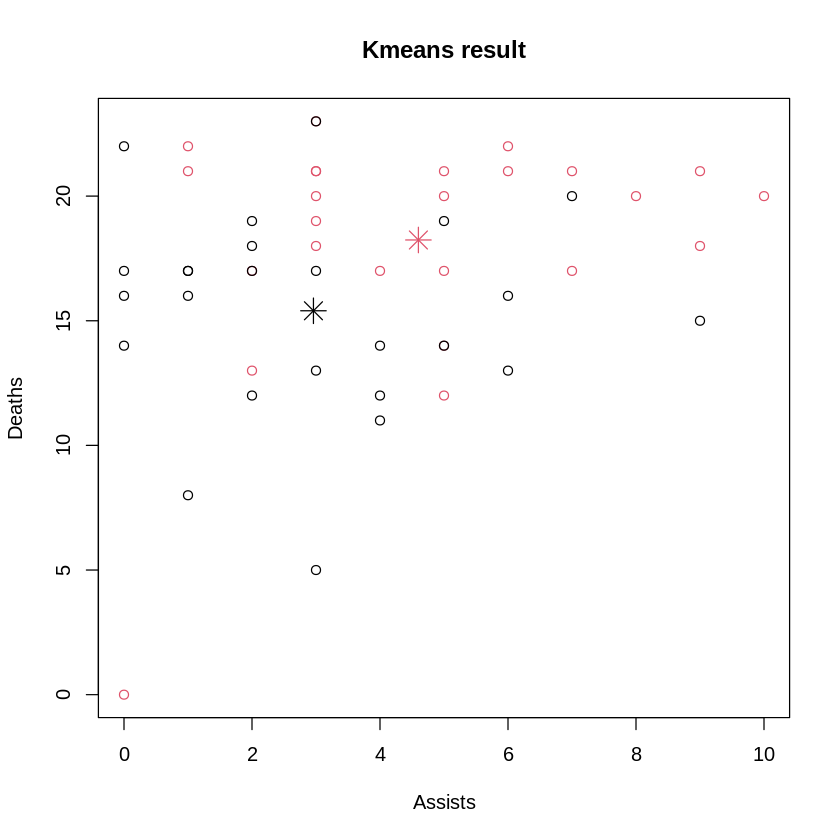

In [19]:
# Visualize with scatter plot
plot(databaru[c("Assists", "Deaths")], col=
  kmeans.awal$cluster, main = "Kmeans result" )
points(kmeans.awal$centers[,c("Assists", "Deaths")],
  col= 1:2, pch = 8, cex =2)

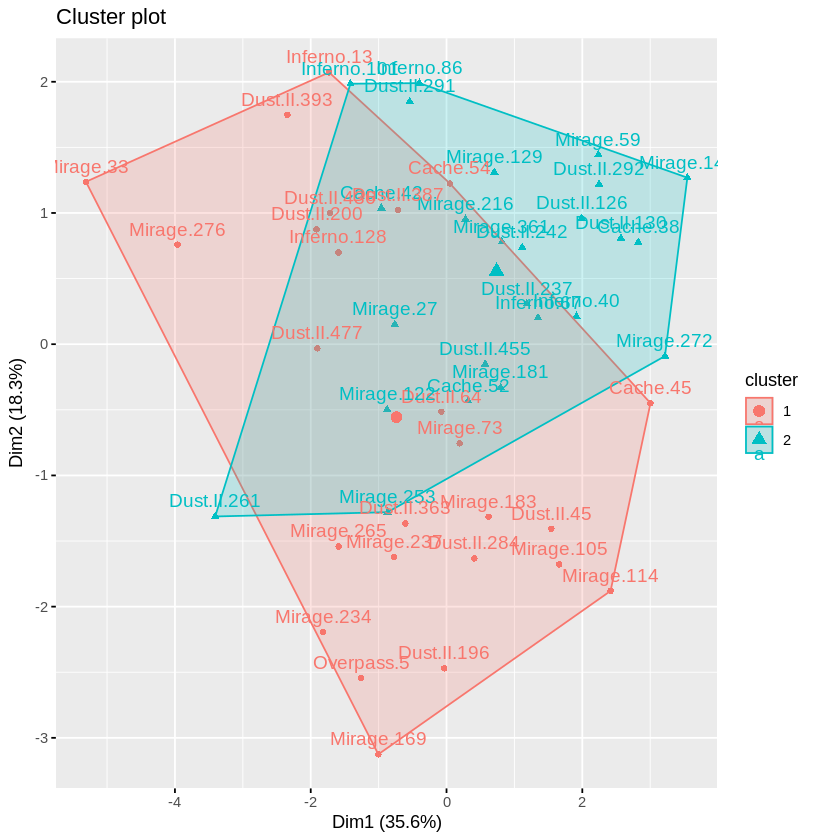

In [20]:
# Visualize with fviz_cluster
fviz_cluster(kmeans.awal, databaru)